
# Logistic Regression for Agriculture Decision-Making

**Turning Farm Data into Yes/No Decisions**  
Simple idea. Powerful outcomes. Foundation of risk-based advisories.

This notebook is designed for **Google Colab / Jupyter Notebook** and is aligned with the provided teaching document.



## Why Logistic Regression Matters in Agriculture

Many farming decisions are **binary classification problems**:
- Will frost damage occur?
- Is the crop diseased?
- Should irrigation be activated?

Logistic Regression helps convert uncertainty into **actionable risk-based decisions**.



## Core Concept: Probability, Not Quantity

Logistic Regression:
- Predicts **probability (0–1)**
- Converts probability into **Yes / No decisions**
- Uses the **Sigmoid function** as a smooth risk meter


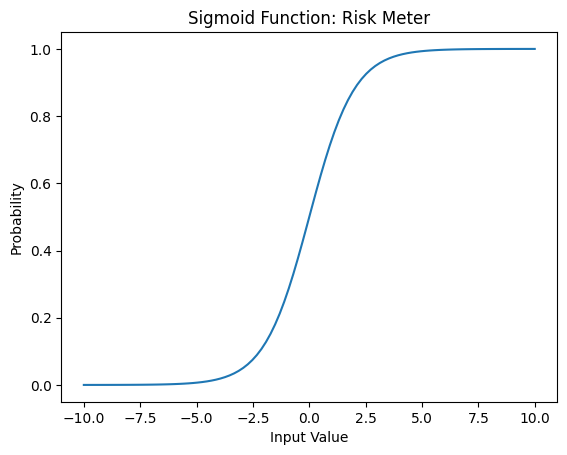

In [1]:

import numpy as np
import matplotlib.pyplot as plt

# Sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-10, 10, 100)
plt.plot(z, sigmoid(z))
plt.xlabel("Input Value")
plt.ylabel("Probability")
plt.title("Sigmoid Function: Risk Meter")
plt.show()



## Example Farming Scenario

**Inputs**
- Minimum Night Temperature (°C)
- Humidity (%)

**Output**
- Frost Damage Risk (Yes = 1, No = 0)



## Sample Dataset (Frost Risk)
Each row represents one night's weather conditions.


In [2]:

import pandas as pd

data = {
    "Min_Temp_C": [2, 4, 6, 8, 1, 3, 7, 5],
    "Humidity": [90, 85, 70, 60, 95, 88, 65, 75],
    "Frost_Damage": [1, 1, 0, 0, 1, 1, 0, 0]
}

df = pd.DataFrame(data)
df


,Min_Temp_C,Humidity,Frost_Damage
0,2,90,1
1,4,85,1
2,6,70,0
3,8,60,0
4,1,95,1
5,3,88,1
6,7,65,0
7,5,75,0



## Building the Logistic Regression Model

This is a **supervised learning** problem:
- Inputs: Weather conditions
- Output: Frost damage (Yes / No)


In [3]:

from sklearn.linear_model import LogisticRegression

X = df[["Min_Temp_C", "Humidity"]]
y = df["Frost_Damage"]

model = LogisticRegression()
model.fit(X, y)

model


LogisticRegression()


## Predicting Frost Damage Probability
The model estimates **risk**, not certainty.


In [4]:

# Predict probability for a cold and humid night
probability = model.predict_proba([[3, 90]])
probability


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([[0.0022704, 0.9977296]])


**Interpretation:**  
There is a high probability of frost damage → **Prepare protection measures**.



## Converting Probability into Yes / No Decision
Default threshold = 0.5 (50%)


In [5]:

model.predict([[3, 90]])


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([1])


## Model Evaluation: Confusion Matrix
Important for **early-warning systems**.


In [6]:

from sklearn.metrics import confusion_matrix, accuracy_score

y_pred = model.predict(X)

conf_matrix = confusion_matrix(y, y_pred)
accuracy = accuracy_score(y, y_pred)

conf_matrix, accuracy


(array([[4, 0],
        [0, 4]]),
 1.0)


### Why Accuracy Alone Is Not Enough

- Frost events are **rare**
- Missing an event (False Negative) is **costly**
- Precision and Recall are crucial in agriculture



## Real Agriculture Case Study: Frost Advisory System

- Logistic Regression applied to weather data
- Alerts triggered when risk > 70%
- Result: Reduced crop loss and timely farmer action



## Key Takeaways

- Logistic Regression enables **probability-based decisions**
- Sigmoid function acts as a **risk meter**
- Confusion matrix evaluates warning quality
- Essential for **precision agriculture and risk advisories**
